In [4737]:
%matplotlib inline
import os
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [4738]:
import pandas as pd

import numpy as np

# Import thêm các hàm cần thiết để tính toán chỉ số đánh giá mô hình

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



# ==========================================

# SETTINGS

# ==========================================



np.random.seed(42)

n = 3000



# ==========================================

# HOUSE ID

# ==========================================



house_id = [f"VN_{i+1:04d}" for i in range(n)]



# ==========================================

# REGION

# ==========================================



regions = np.random.choice(

    ["Hanoi", "HCMC", "Big_Province", "Small_Province"],

    size=n,

    p=[0.12, 0.15, 0.43, 0.30]  # Hà Nội + HCMC chiếm ~27%, Tỉnh lớn 43%, Tỉnh nhỏ 30%

)



# ==========================================

# AREA (m²)

# ==========================================



area = np.random.lognormal(mean=4.3, sigma=0.5, size=n)



# Điều chỉnh và ép sàn/trần thực tế cho toàn VN (từ 18m2 đến 600m2)

area = np.clip(area * 1.2, 18.0, 600.0)



# ==========================================

# FRONTAGE (m)

# ==========================================



frontage = (

    4

    + area / 85

    + np.random.normal(0, 1.8, n)

)



frontage = np.clip(frontage, 3, 20)



# ==========================================

# ROAD WIDTH (m)

# ==========================================



road_width = (

    frontage * 0.75

    + np.random.normal(0, 1.5, n)

)



road_width = np.clip(road_width, 2, 20)



# ==========================================

# DISTANCE TO CENTER (km)

# ==========================================



distance_to_center = np.random.uniform(1, 35, n)



# ==========================================

# FLOORS

# ==========================================



floors = np.round(

    1

    + area / 70

    + np.random.normal(0, 0.8, n)

).astype(int)



floors = np.clip(floors, 1, 5)



# ==========================================

# YEAR BUILT

# ==========================================



year_built = np.random.randint(1980, 2026, n)



# ==========================================

# BEDROOMS

# ==========================================



bedrooms = np.round(

    area / 45

    + np.random.normal(0, 1.3, n)

).astype(int)



bedrooms = np.clip(bedrooms, 1, 7)



# ==========================================

# BATHROOMS

# ==========================================



bathrooms = np.round(

    bedrooms * 0.70

    + np.random.normal(0, 0.9, n)

).astype(int)



bathrooms = np.clip(bathrooms, 1, 5)

bathrooms = np.minimum(bathrooms, bedrooms)



# ==========================================

# REGION FACTOR

# ==========================================



region_factor = {

    "HCMC": 8.50,           # Trung bình giá đất HCMC cao gấp ~8.5 lần tỉnh lớn

    "Hanoi": 8.00,          # Trung bình giá đất Hà Nội cao gấp ~8.0 lần tỉnh lớn

    "Big_Province": 1.00,   # Mốc chuẩn (Base)

    "Small_Province": 0.25  # Các tỉnh nghèo, vùng sâu vùng xa bằng 1/4 tỉnh lớn (gấp ~34 lần so với HCMC)

}



# 4. ÁNH XẠ SANG MẢNG SỐ THỰC

region_multiplier = np.array(

    [region_factor[r] for r in regions]

)



# ==========================================

# PRICE GENERATION (HIỆU CHỈNH HỆ SỐ CHUẨN KINH TẾ)

# ==========================================



noise = np.random.normal(0, 0.1, n)



base_price = (10 * np.exp(-distance_to_center / 7.0) + 1.5) * (region_multiplier**0.5)



# --- 2. TÍNH TOÁN GIÁ NHÀ TOÀN DIỆN (Điều chỉnh số mũ để xếp hạng tương quan) ---
price_scale = 1

price = (
    price_scale
    * base_price
    * (area / 100.0) ** 0.7
    * (road_width / 5.0) ** 0.5
    * (1.0 + (frontage - 4.0) * 0.035)
    * (1.0 + (floors - 2) * 0.015)
    * (1.0 + (year_built - 2000) * 0.002)
    * (1.0 / (1.0 + (bedrooms - 2) * 0.01))
)



# --- 3. THÊM NHIỄU VÀ GIỚI HẠN TRẦN/SÀN ---

price *= (1.0 + noise)


# Nới trần clip lên một chút vì có hệ số HCMC/Hanoi lớn, giá nhà trung tâm sẽ rất cao

# price = np.clip(price, 0.5, 150.0)



# ==========================================

# DATAFRAME

# ==========================================



df = pd.DataFrame({

    "House_ID": house_id,

    "Region": regions,

    "Region_Factor": region_multiplier,  # Cột số duy nhất phục vụ tính toán và thẩm mỹ corr

    "Area": np.round(area, 1),

    "Frontage": np.round(frontage, 1),

    "Road_Width": np.round(road_width, 1),

    "dist-center": np.round(distance_to_center, 1),

    "Floors": floors,

    "Bedrooms": bedrooms,

    "Bathrooms": bathrooms,

    "yr-built": year_built,

    "Price": np.round(price, 2)

})



file_name = "vietnam_house_prices_1000.csv"

df.to_csv(file_name, index=False, encoding="utf-8-sig")



# ==========================================

# KIỂM TRA ĐẦU RA GỐC

# ==========================================



print("=== STATS ===")

print(df["Price"].describe())



print("\n=== PERCENT > 30 BILLION ===")

print(f"{(df['Price'] > 30).mean() * 100:.2f}%")



print("\n=== CORRELATION ===")

print(

    df.corr(numeric_only=True)["Price"]

      .sort_values(ascending=False)

)



# ==========================================

# THÊM ĐOẠN IN ĐÁNH GIÁ MÔ HÌNH (R2, MAE, MSE, RMSE)

# ==========================================

print("\n" + "="*45)

print("=== METRICS EVALUATION (LINEAR REGRESSION) ===")

print("="*45)



# Chuyển đổi biến phân loại 'Region' thành dạng số qua One-Hot Encoding

df_ml = pd.get_dummies(df.drop(columns=["House_ID"]), columns=["Region"], drop_first=True)



# Tách đặc trưng (X) và nhãn (y)

X = df_ml.drop(columns=["Price"])

y = df_ml["Price"]



# Chia dữ liệu Train/Test theo tỷ lệ 80/20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Lấy log của Price để đưa mối quan hệ nhân về tuyến tính

y_train_log = np.log(y_train)



model = LinearRegression()

model.fit(X_train, y_train_log)



# Khi dự đoán xong thì dùng hàm mũ ngược lại (exp) để tính chỉ số

y_pred_log = model.predict(X_test)

y_pred = np.exp(y_pred_log)



# Tính lại R2, MAE... lúc này R2 sẽ tăng vọt!



# Tính toán các chỉ số lỗi toán học

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)



# In kết quả đánh giá ra màn hình

print(f"R2 Score (Hệ số xác định)           : {r2}")

print(f"MAE (Sai số tuyệt đối trung bình)     : {mae} Tỷ VND")

print(f"MSE (Sai số bình phương trung bình)   : {mse}")

print(f"RMSE (Căn sai số bình phương trung bình): {rmse} Tỷ VND") 





=== STATS ===
count    3000.000000
mean        4.081263
std         5.209670
min         0.160000
25%         1.140000
50%         2.310000
75%         4.870000
max        55.510000
Name: Price, dtype: float64

=== PERCENT > 30 BILLION ===
0.53%

=== CORRELATION ===
Price            1.000000
Region_Factor    0.536815
Area             0.365733
Frontage         0.269085
Road_Width       0.256351
Floors           0.233880
Bedrooms         0.232851
Bathrooms        0.191806
yr-built         0.030004
dist-center     -0.457058
Name: Price, dtype: float64

=== METRICS EVALUATION (LINEAR REGRESSION) ===
R2 Score (Hệ số xác định)           : 0.8951055041554941
MAE (Sai số tuyệt đối trung bình)     : 0.7921911429784176 Tỷ VND
MSE (Sai số bình phương trung bình)   : 2.8864779184893603
RMSE (Căn sai số bình phương trung bình): 1.6989637778626596 Tỷ VND


In [4739]:
df = pd.read_csv("data/vietnam_house_prices_1000.csv")
df

,House_ID,Region,Region_Factor,Area,Frontage,Road_Width,dist-center,Floors,Bedrooms,Bathrooms,yr-built,Price
0,VN_0001,Big_Province,1.00,150.2,6.9,2.9,21.8,3,1,1,1981,2.19
1,VN_0002,Small_Province,0.25,120.4,6.1,3.7,8.6,2,3,3,1987,2.30
2,VN_0003,Small_Province,0.25,124.5,5.8,5.0,21.8,1,2,2,2001,1.34
3,VN_0004,Big_Province,1.00,44.7,6.6,6.1,22.4,2,1,1,1992,1.07
4,VN_0005,HCMC,8.50,162.1,4.9,7.0,26.0,5,3,2,2000,8.43
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,VN_2996,Small_Province,0.25,204.3,7.0,4.6,17.6,3,5,5,1992,1.81
2996,VN_2997,HCMC,8.50,77.1,4.2,2.8,4.8,2,1,1,2015,13.30
2997,VN_2998,Big_Province,1.00,29.4,4.9,5.7,17.0,1,1,1,1994,1.15
2998,VN_2999,Big_Province,1.00,32.6,5.4,6.2,9.3,1,1,1,1985,2.08


In [4740]:
print(df["Price"].describe())

print((df["Price"] > 30).mean() * 100)

print(
    df.corr(numeric_only=True)["Price"]
    .sort_values(ascending=False)
)

count    3000.000000
mean        4.081263
std         5.209670
min         0.160000
25%         1.140000
50%         2.310000
75%         4.870000
max        55.510000
Name: Price, dtype: float64
0.5333333333333333
Price            1.000000
Region_Factor    0.536815
Area             0.365733
Frontage         0.269085
Road_Width       0.256351
Floors           0.233880
Bedrooms         0.232851
Bathrooms        0.191806
yr-built         0.030004
dist-center     -0.457058
Name: Price, dtype: float64


In [4741]:
print(df["Price"].describe())

print(
    '(df["Price"] > 30).mean() * 100 =',
    (df["Price"] > 30).mean() * 100
)

count    3000.000000
mean        4.081263
std         5.209670
min         0.160000
25%         1.140000
50%         2.310000
75%         4.870000
max        55.510000
Name: Price, dtype: float64
(df["Price"] > 30).mean() * 100 = 0.5333333333333333


In [4742]:
print(
    df.corr(numeric_only=True)["Price"]
    .sort_values(ascending=False)
)

Price            1.000000
Region_Factor    0.536815
Area             0.365733
Frontage         0.269085
Road_Width       0.256351
Floors           0.233880
Bedrooms         0.232851
Bathrooms        0.191806
yr-built         0.030004
dist-center     -0.457058
Name: Price, dtype: float64


In [4743]:
print('mean:', df["Price"].mean())
print('median:', df["Price"].median())
print('min:', df["Price"].min())
print('max:', df["Price"].max())

mean: 4.081263333333333
median: 2.31
min: 0.16
max: 55.51


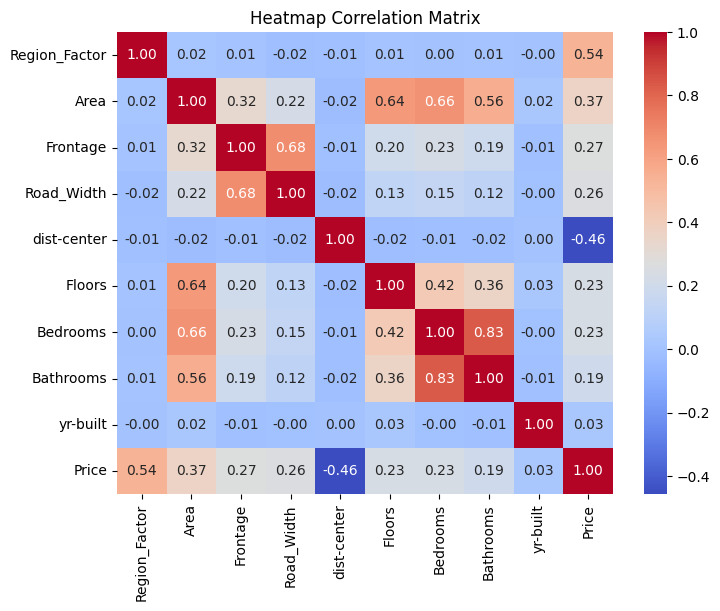

In [4744]:
# Chỉ lấy các cột số
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Ma trận tương quan
corr_matrix = numeric_df.corr()

# Vẽ heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Heatmap Correlation Matrix')
plt.show()
# corr = df.corr(numeric_only=True)
# print(corr)

<Axes: xlabel='Region', ylabel='Price'>

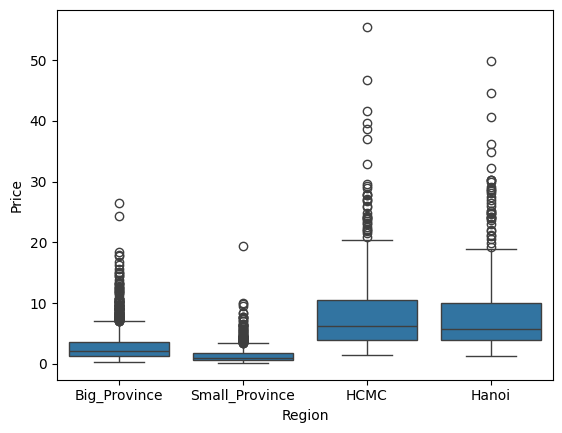

In [4745]:
sns.boxplot(
    data=df,
    x="Region",
    y="Price"
)

In [4746]:
df[["Price", "Region"]].groupby("Region").mean()

,Price
Region,
Big_Province,3.060133
HCMC,8.657110
Hanoi,8.499039
Small_Province,1.479901


In [4747]:
df["yr-built"].mean()

np.float64(2002.7363333333333)

In [4748]:
df["Price"].mean()

np.float64(4.081263333333333)

In [4749]:
df["Floors"].mean()

np.float64(2.4476666666666667)

In [4750]:
df["Region"].mode()

0    Big_Province
Name: Region, dtype: object

In [4751]:
df["Area"].mean()


np.float64(99.2288)

In [4752]:
df["Road_Width"].mean()

np.float64(4.085466666666666)

In [4753]:
df["Frontage"].mean()

np.float64(5.268300000000001)

In [4754]:
df["dist-center"].mean()

np.float64(18.246599999999997)

In [4755]:
df["Floors"].mean()

np.float64(2.4476666666666667)

In [4756]:
df["Bedrooms"].mean()

np.float64(2.4286666666666665)

In [4757]:
X = df.iloc[:, [2,3,4,5,6,7,8]]
y = df.iloc[:, [9]]
X.columns, y.columns

(Index(['Region_Factor', 'Area', 'Frontage', 'Road_Width', 'dist-center',
        'Floors', 'Bedrooms'],
       dtype='object'),
 Index(['Bathrooms'], dtype='object'))

In [4758]:
# Import hàm chia dữ liệu train_test_split từ Scikit-learn.

from sklearn.model_selection import train_test_split
# Import các thang đo hiệu năng: MSE (Sai số bình phương trung bình) và R2 Score (Hệ số xác định).
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train, y_train)
print(X_test, y_test)

      Region_Factor   Area  Frontage  Road_Width  dist-center  Floors  \
642            8.50   91.7       3.3         2.2         17.0       2   
700            1.00   44.5       7.0         5.9         31.7       1   
226            0.25  183.9       5.0         3.7         24.8       3   
1697           8.50  361.3       8.1         6.4          6.4       5   
1010           8.50   49.7       6.2         6.8          8.3       3   
...             ...    ...       ...         ...          ...     ...   
1638           0.25  231.4       6.7         3.5         26.8       3   
1095           8.50   50.0       3.0         2.0         13.9       2   
1130           0.25   76.0       6.1         5.5          2.7       3   
1294           0.25   59.0       3.0         2.0         15.2       1   
860            0.25  159.8       7.7         3.6         13.3       2   

      Bedrooms  
642          3  
700          1  
226          5  
1697         7  
1010         1  
...        ...  
1638

In [4759]:
model = LinearRegression()
model.fit(X_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4760]:
y_pred = model.predict(X_test) # Kiểm tra
print(y_pred)

[[2.73260897]
 [2.13121818]
 [0.93877398]
 [2.13589441]
 [4.55891334]
 [2.71608476]
 [1.55652762]
 [0.97183379]
 [0.92879151]
 [1.53815533]
 [0.92713849]
 [1.51091247]
 [0.94784099]
 [2.10928938]
 [0.96754361]
 [1.57079396]
 [2.13825681]
 [2.13637769]
 [2.13277589]
 [0.95007876]
 [0.9669271 ]
 [1.55500864]
 [0.93202555]
 [1.52846103]
 [1.52048165]
 [0.94553417]
 [1.55151459]
 [0.93977944]
 [1.54029767]
 [0.96544856]
 [1.53254666]
 [0.93426706]
 [0.98055865]
 [2.721745  ]
 [0.97043747]
 [0.92905189]
 [1.55334107]
 [2.12395674]
 [0.93580247]
 [2.71861472]
 [2.7776583 ]
 [0.93162953]
 [0.95508873]
 [0.96439762]
 [2.73375657]
 [0.96646852]
 [3.88708964]
 [1.53053548]
 [0.9516372 ]
 [2.1443873 ]
 [1.54728427]
 [3.94927102]
 [2.70163143]
 [2.73331953]
 [1.52165875]
 [2.11106228]
 [2.72407311]
 [2.72848304]
 [2.76085397]
 [2.11589038]
 [2.11918847]
 [0.94049727]
 [4.53955282]
 [1.53656504]
 [1.52598366]
 [1.53992101]
 [0.93454463]
 [0.92936518]
 [1.53907047]
 [1.54266429]
 [0.96931041]
 [0.95

In [4761]:
r2 = r2_score(y_test, y_pred) # đo xu hướng tổng quảt
mse = mean_squared_error(y_test, y_pred) # đo sai số cụ thể
r2, mse 

(0.6767596616111788, 0.3760326687663464)

In [4762]:
df = pd.read_csv("data/test_data.csv")
df

,House_ID,Region,Area,Frontage,w-road,Distance,Floors,Bedrooms,Bathrooms,built-yr
0,0,Thành phố Hồ Chí Minh,50.00,5.0,9.0,6.0,3,3,3,2000
1,1,Hà Nội,141.28,6.1,4.8,18.0,3,3,2,2003
2,100,Thành phố Hồ Chí Minh,1000.00,25.0,15.0,0.1,10,12,10,2018
3,6,Hà Nội,50.00,3.0,4.0,10.0,3,3,3,2000
4,67,Thành phố Hồ Chí Minh,120.00,6.5,10.0,3.5,4,3,3,2018
5,677,Hà Nội,85.00,5.5,6.5,8.0,3,3,2,2012
6,6777,Tỉnh lớn,60.00,4.5,4.5,15.0,2,2,2,2005
7,1000,Thành phố Hồ Chí Minh,250.00,12.0,20.0,1.0,5,6,5,2024
8,1001,Thành phố Hồ Chí Minh,250.00,12.0,5.0,1.0,5,6,5,2024
9,61,Thành phố Hồ Chí Minh,67.00,6.7,6.7,67.0,6,7,3,1999


In [4763]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# 1. ĐỌC DATASET HUẤN LUYỆN
# =========================

df = pd.read_csv("data/vietnam_house_prices_1000.csv")

# =========================
# 2. MÃ HÓA REGION
# =========================

region_map = {
    "S-tỉnh": 0,
    "B-tỉnh": 1,
    "Hanoi": 2,
    "HCMC": 3
}

df["Region_Code"] = df["Region"].map(region_map)

# =========================
# 3. TẠO X VÀ y
# =========================

X = df[
    [
        "Region_Code",
        "Area",
        "Frontage",
        "Road_Width",
        "dist-center",
        "Floors",
        "Bedrooms",
        "Bathrooms",
        "yr-built"
    ]
]

y = df["Price"]

# =========================
# 4. CHIA TRAIN / TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# =========================
# 5. HUẤN LUYỆN MÔ HÌNH
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. ĐÁNH GIÁ MÔ HÌNH
# =========================

y_pred = model.predict(X_test)

print("========== ĐÁNH GIÁ MÔ HÌNH ==========")

print(
    "R² Score:",
    r2_score(y_test, y_pred)
)

print(
    "MAE:",
    mean_absolute_error(y_test, y_pred)
)

print(
    "RMSE:",
        mean_squared_error(
            y_test,
            y_pred
        ) ** 0.5
)

# # =========================
# # 7. ĐỌC DỮ LIỆU CẦN DỰ ĐOÁN
# # =========================

# test_df = pd.read_csv("data/test_data.csv")

# # =========================
# # 8. MÃ HÓA REGION CHO TEST
# # =========================

# test_region_map = {
#     "Tỉnh nhỏ": 0,
#     "Tỉnh lớn": 1,
#     "Hà Nội": 2,
#     "Thành phố Hồ Chí Minh": 3
# }

# test_df["Region_Code"] = test_df["Region"].map(
#     test_region_map
# )

# # =========================
# # 9. TẠO X_new
# # =========================

# X_new = pd.DataFrame({
#     "Region_Code": test_df["Region_Code"],
#     "Area": test_df["Area"],
#     "Frontage": test_df["Frontage"],
#     "dist-center": test_df["Distance"],
#     "Floors": test_df["Floors"],
#     "Bedrooms": test_df["Bedrooms"],
#     "Bathrooms": test_df["Bathrooms"],
#     "yr-built": test_df["built-yr"]
# })

# # =========================
# # 10. DỰ ĐOÁN
# # =========================

# predictions = model.predict(X_new)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R² =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))

R² = 0.5652224017240172
MAE = 8.752432406445095


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

model = LinearRegression()

# Định nghĩa các chỉ số bạn muốn đo lường
metrics = ["r2", "neg_mean_absolute_error"]

# Chạy Cross Validation
cv_results = cross_validate(model, X, y, cv=5, scoring=metrics)

# Lưu ý: scikit-learn mặc định tính MAE dưới dạng số âm (Negative MAE) để tối ưu toán học.
# Chúng ta chỉ cần đổi dấu lại thành số dương để đọc.
mae_scores = -cv_results["test_neg_mean_absolute_error"]
r2_scores = cv_results["test_r2"]

print(f"R² trung bình qua 5 lần: {r2_scores.mean()}")
print(f"MAE trung bình qua 5 lần: {mae_scores.mean()}")
from sklearn.metrics import max_error

# Tính sai số lớn nhất
worst_mistake = max_error(y_test, y_pred)
print(f"Sai số lớn nhất (Trường hợp tệ nhất): {worst_mistake}")
# Tính sai số tuyệt đối của từng căn nhà
absolute_errors = np.abs(y_test - y_pred)

# Tìm sai số nhỏ nhất
min_err = np.min(absolute_errors)
print(f"Sai số nhỏ nhất (Đoán chuẩn nhất): {min_err}")

R² trung bình qua 5 lần: 0.5431681324810674
MAE trung bình qua 5 lần: 8.998893529133472
Sai số lớn nhất (Trường hợp tệ nhất): 103.82243599661695
Sai số nhỏ nhất (Đoán chuẩn nhất): 0.026219308141546716
